# Documentation:

In task 1, I checked if every image has a matching label file. Because if some images are missing labels YOLO will either crash or silently skip them during training.I also looked at the class distribution because if one class has way more examples than another, the model will naturally get better at detecting the
common one. In this case we only have cats so it's not a big issue tbh. Then I checked image sizes on 100 random samples instead of all of them just to save
time (deadline was near).

In [3]:
!pip install ultralytics torch torchvision matplotlib pandas pillow opencv-python -q

In [4]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Copying dataset from Drive to Colab local storage
import shutil, os

DRIVE_DATASET = "/content/drive/MyDrive/DATA_CLEAN"
LOCAL_DATASET = "/content/data/DATA_CLEAN"

if not os.path.exists(LOCAL_DATASET):
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
    print("Dataset copied.")
else:
    print("Already exists, skipping copy.")

Dataset copied.


# Task 1 — Inspect the Dataset

In [6]:
# Counting images and labels, check matching
import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

IMG_DIR = "/content/data/DATA_CLEAN/images"
LBL_DIR = "/content/data/DATA_CLEAN/labels"

# If images and labels are in the same folder, adjusting these paths
image_exts = {".jpg", ".jpeg", ".png"}

image_files = {os.path.splitext(f)[0]: f for f in os.listdir(IMG_DIR)
               if os.path.splitext(f)[1].lower() in image_exts}
label_files = {os.path.splitext(f)[0]: f for f in os.listdir(LBL_DIR)
               if f.endswith(".txt")}

print(f"Total images:      {len(image_files)}")
print(f"Total label files: {len(label_files)}")

imgs_no_label = set(image_files) - set(label_files)
labels_no_img = set(label_files) - set(image_files)
print(f"\nImages WITHOUT a label file: {len(imgs_no_label)}")
print(f"Labels WITHOUT an image file: {len(labels_no_img)}")
if imgs_no_label:
    print("  Examples:", list(imgs_no_label)[:5])

Total images:      3327
Total label files: 3327

Images WITHOUT a label file: 0
Labels WITHOUT an image file: 0


Class ID → Object Count:
  Class 0: 3895 objects


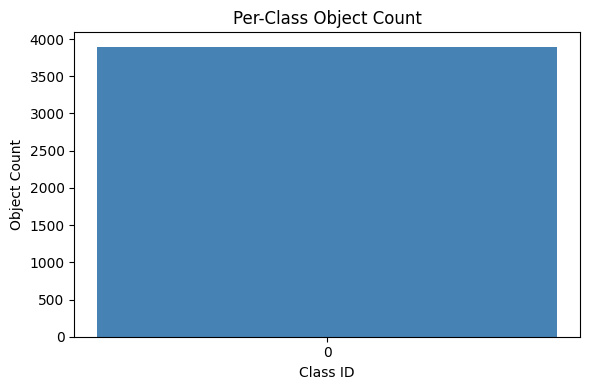

In [7]:
# Class distribution
class_counts = defaultdict(int)

for stem, lbl_name in label_files.items():
    lbl_path = os.path.join(LBL_DIR, lbl_name)
    with open(lbl_path) as f:
        for line in f:
            line = line.strip()
            if line:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

print("Class ID → Object Count:")
for cid, count in sorted(class_counts.items()):
    print(f"  Class {cid}: {count} objects")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar([str(k) for k in sorted(class_counts)],
        [class_counts[k] for k in sorted(class_counts)],
        color="steelblue")
plt.xlabel("Class ID")
plt.ylabel("Object Count")
plt.title("Per-Class Object Count")
plt.tight_layout()
plt.show()

In [8]:
# Image size statistics (100 random images)
all_stems = list(image_files.keys())
sample_stems = random.sample(all_stems, min(100, len(all_stems)))

widths, heights = [], []
for stem in sample_stems:
    img_path = os.path.join(IMG_DIR, image_files[stem])
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")

Width  — min: 640, max: 6016, mean: 2817.1
Height — min: 640, max: 4608, mean: 2138.8


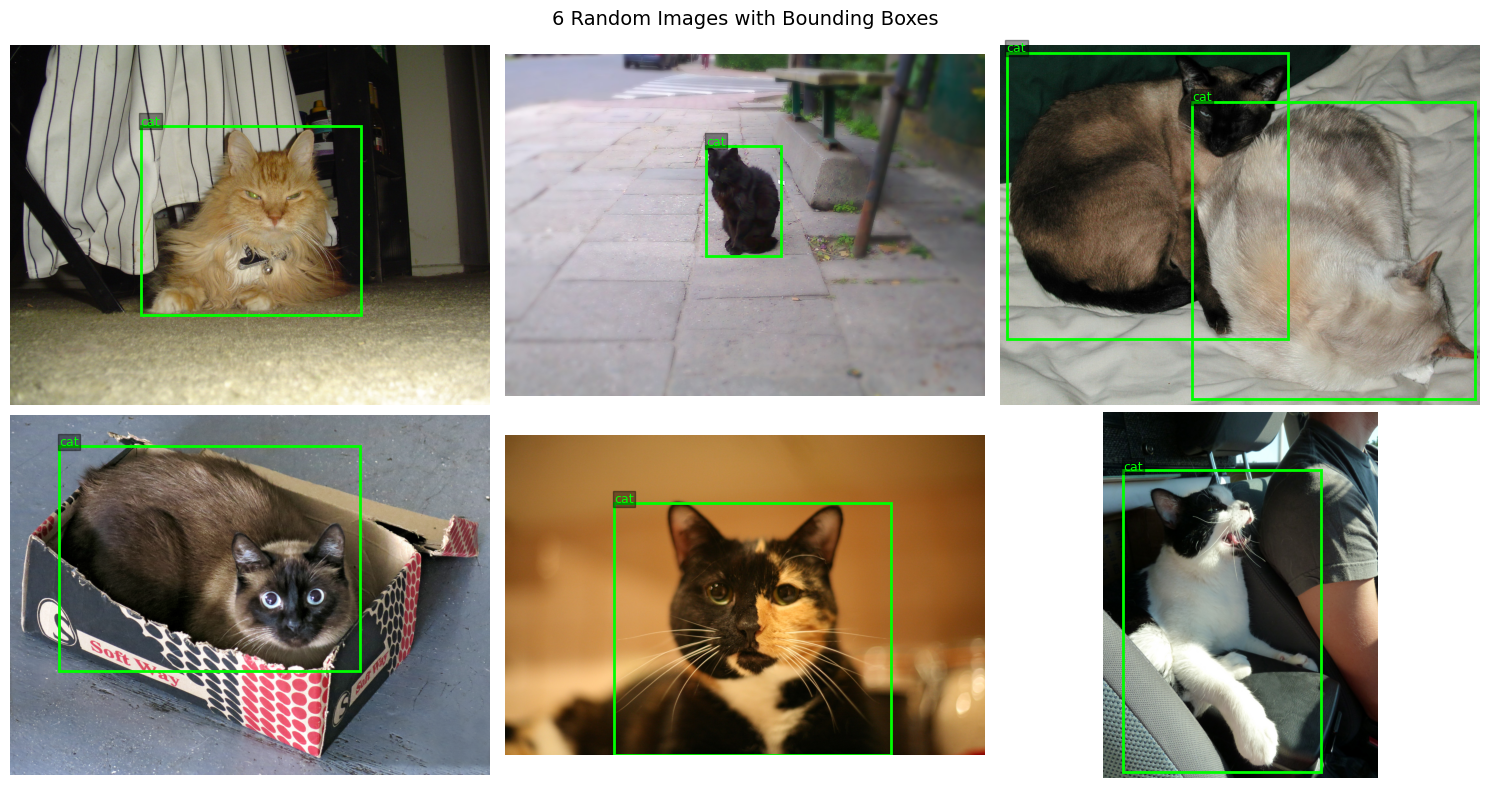

In [9]:
# Visualise 6 random images with bounding boxes (2×3 grid)
CLASS_NAMES = {0: "cat"}

def draw_boxes(ax, img, lbl_path):
    w, h = img.size
    ax.imshow(img)
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                         linewidth=2, edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, CLASS_NAMES.get(cid, str(cid)),
                        color="lime", fontsize=9,
                        bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax.axis("off")

sample6 = random.sample(all_stems, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, stem in zip(axes.flat, sample6):
    img = Image.open(os.path.join(IMG_DIR, image_files[stem]))
    lbl = os.path.join(LBL_DIR, label_files.get(stem, ""))
    draw_boxes(ax, img, lbl)
plt.suptitle("6 Random Images with Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.show()

# Task 2 — Train / Val / Test Splits + data.yaml

In [10]:
# Create splits and write text files
import random

random.seed(42)
matched_stems = sorted(set(image_files) & set(label_files))
random.shuffle(matched_stems)

n = len(matched_stems)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_stems = matched_stems[:n_train]
val_stems   = matched_stems[n_train : n_train + n_val]
test_stems  = matched_stems[n_train + n_val:]

print(f"Train: {len(train_stems)} | Val: {len(val_stems)} | Test: {len(test_stems)}")

SPLIT_DIR = "/content/data/DATA_CLEAN"
os.makedirs(SPLIT_DIR, exist_ok=True)

for split_name, stems in [("train", train_stems), ("val", val_stems), ("test", test_stems)]:
    with open(os.path.join(SPLIT_DIR, f"{split_name}.txt"), "w") as f:
        for stem in stems:
            f.write(os.path.join(IMG_DIR, image_files[stem]) + "\n")

print("Split .txt files written.")

Train: 2328 | Val: 499 | Test: 500
Split .txt files written.


In [11]:
# Write data.yaml
import yaml

data_yaml = {
    "path": "/content/data",
    "train": "DATA_CLEAN/train.txt",
    "val":   "DATA_CLEAN/val.txt",
    "test":  "DATA_CLEAN/test.txt",
    "names": {0: "cat"},   # ← add other class IDs here if needed
}

yaml_path = "/content/data/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("data.yaml written:")
print(open(yaml_path).read())

data.yaml written:
path: /content/data
train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt
names:
  0: cat



# Task 3 — Train YOLO26

I chose the YOLO26n variant for this project. Since the dataset contains around 3500 images, a lightweight model is sufficient for achieving reasonable detection performance while keeping training time manageable. My available hardware includes a laptop with 16 GB RAM and an NVIDIA MX330 GPU with 2 GB VRAM, which is not powerful enough for comfortably training larger YOLO26 variants locally.

Another reason for choosing YOLO26n is that this same model will later be exported to ONNX and deployed inside a Docker container. The nano variant produces a much smaller and faster model, making deployment and inference more practical for the next assessment.

In [12]:
# Loading model and training
from ultralytics import YOLO

VARIANT = "n"

model = YOLO(f"yolo26{VARIANT}.pt")   # downloads COCO-pretrained weights automatically

results = model.train(
    data="/content/data/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    project="/content/runs",
    name="cats_v1",
    seed=42,
    verbose=True,
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

EOFError: No data left in file

In [1]:
# Training curves
from IPython.display import Image as IPyImage

results_png = "/content/runs/cats_v1/results.png"
IPyImage(results_png, width=900)

FileNotFoundError: No such file or directory: '/content/runs/cats_v1/results.png'

FileNotFoundError: No such file or directory: '/content/runs/cats_v1/results.png'

<IPython.core.display.Image object>

In [2]:
# Extracting and print best validation metrics
import pandas as pd

results_csv = "/content/runs/cats_v1/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Column names vary slightly by ultralytics version — print them to verify
print("Columns:", df.columns.tolist())

map50_col     = [c for c in df.columns if "metrics/mAP50("    in c][0]
map50_95_col  = [c for c in df.columns if "metrics/mAP50-95(" in c][0]

best_idx    = df[map50_col].idxmax()
best_epoch  = int(df.loc[best_idx, "epoch"]) + 1   # 1-indexed
best_map50  = df.loc[best_idx, map50_col]
best_map5095= df.loc[best_idx, map50_95_col]

print(f"\nBest mAP@0.5       : {best_map50:.4f}")
print(f"Best mAP@0.5:0.95  : {best_map5095:.4f}")
print(f"Achieved at epoch  : {best_epoch}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/cats_v1/results.csv'

# Task 4 — Evaluate on Test Set

In [3]:
# Run validation on the test split with the best checkpoint
best_ckpt = "/content/runs/cats_v1/weights/best.pt"
model_eval = YOLO(best_ckpt)

metrics = model_eval.val(
    data="/content/data/data.yaml",
    split="test",
    imgsz=640,
)

map50    = metrics.box.map50
map5095  = metrics.box.map
precision= metrics.box.mp
recall   = metrics.box.mr

print("Test-Set Metrics")
print(f"{'Metric':<22} {'Value':>8}")
print(f"{'mAP@0.5':<22} {map50:>8.4f}")
print(f"{'mAP@0.5:0.95':<22} {map5095:>8.4f}")
print(f"{'Mean Precision':<22} {precision:>8.4f}")
print(f"{'Mean Recall':<22} {recall:>8.4f}")

NameError: name 'YOLO' is not defined

### Metric explanation

mAP@0.5 — mean Average Precision at IoU threshold 0.5; a detection counts as correct if the predicted box overlaps the ground-truth box by ≥ 50%.

mAP@0.5:0.95 — averages mAP over IoU thresholds from 0.50 to 0.95 in steps of 0.05; a stricter, COCO-standard measure of localisation quality.

Mean Precision — of all boxes the model predicted, what fraction were actually correct (low = many false positives).

Mean Recall — of all real objects in the images, what fraction did the model find (low = many missed cats).


In [4]:
# Run predictions on 6 test images
import cv2

test_txt = "/content/data/DATA_CLEAN/test.txt"
with open(test_txt) as f:
    test_paths = [line.strip() for line in f if line.strip()]

random.seed(0)
pred_paths = random.sample(test_paths, 6)

pred_results = model_eval.predict(
    source=pred_paths,
    imgsz=640,
    conf=0.25,
    save=False,
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/DATA_CLEAN/test.txt'

In [5]:
# 2×3 grid predicted boxes
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, r in zip(axes.flat, pred_results):
    img_bgr = r.plot()            # BGR numpy array with boxes drawn
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(os.path.basename(r.path), fontsize=8)
    ax.axis("off")

plt.suptitle("Predicted Boxes (conf ≥ 0.25)", fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [6]:
# For 3 images — predicted AND ground-truth boxes side by side
def get_gt_boxes(img_path):
    """Return list of (class_id, cx, cy, bw, bh) from YOLO label."""
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(LBL_DIR, stem + ".txt")
    boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

compare_results = pred_results[:3]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row, r in enumerate(compare_results):
    img = Image.open(r.path).convert("RGB")
    w, h = img.size

    # — Left: ground truth —
    ax_gt = axes[row][0]
    ax_gt.imshow(img)
    for (cid, cx, cy, bw, bh) in get_gt_boxes(r.path):
        x1 = (cx - bw/2) * w; y1 = (cy - bh/2) * h
        rect = patches.Rectangle((x1,y1), bw*w, bh*h,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax_gt.add_patch(rect)
        ax_gt.text(x1, y1-4, CLASS_NAMES.get(cid, str(cid)),
                   color="lime", fontsize=8,
                   bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax_gt.set_title(f"GT — {os.path.basename(r.path)}", fontsize=8)
    ax_gt.axis("off")

    # — Right: prediction —
    ax_pred = axes[row][1]
    img_pred = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
    ax_pred.imshow(img_pred)
    ax_pred.set_title("Prediction", fontsize=8)
    ax_pred.axis("off")

plt.suptitle("Ground Truth (left) vs Predictions (right)", fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'pred_results' is not defined

In [7]:
# Find and show at least 2 failure cases

def count_boxes_predicted(r):
    return len(r.boxes) if r.boxes is not None else 0

def count_gt_boxes(img_path):
    return len(get_gt_boxes(img_path))

# Run predictions on the full test set to find failures
all_pred = model_eval.predict(source=test_paths, imgsz=640, conf=0.25, save=False, verbose=False)

false_negatives = []   # GT has boxes but model predicted none
false_positives = []   # Model predicted boxes but GT has none

for r in all_pred:
    n_pred = count_boxes_predicted(r)
    n_gt   = count_gt_boxes(r.path)
    if n_gt > 0 and n_pred == 0:
        false_negatives.append(r)
    elif n_gt == 0 and n_pred > 0:
        false_positives.append(r)

print(f"False negatives found: {len(false_negatives)}")
print(f"False positives found: {len(false_positives)}")

failures = (false_negatives[:1] + false_positives[:1])
if len(failures) < 2:
    # fall back to images with the biggest GT-vs-pred box count difference
    scored = sorted(all_pred,
                    key=lambda r: abs(count_gt_boxes(r.path) - count_boxes_predicted(r)),
                    reverse=True)
    failures = scored[:2]

fig, axes = plt.subplots(1, len(failures), figsize=(8 * len(failures), 6))
if len(failures) == 1:
    axes = [axes]

for ax, r in zip(axes, failures):
    img_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    n_gt   = count_gt_boxes(r.path)
    n_pred = count_boxes_predicted(r)
    ax.set_title(f"GT boxes: {n_gt} | Pred boxes: {n_pred}\n{os.path.basename(r.path)}",
                 fontsize=9)
    ax.axis("off")

plt.suptitle("Failure Cases", fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'model_eval' is not defined

# Task 6 — Save Everything Back to Drive

In [8]:
# Copy notebook output + weights back to Drive for safety
import shutil

DRIVE_OUT = "/content/drive/MyDrive/m6-04-output"
os.makedirs(DRIVE_OUT, exist_ok=True)

shutil.copy("/content/data/data.yaml", DRIVE_OUT)
shutil.copy("/content/data/DATA_CLEAN/train.txt", DRIVE_OUT)
shutil.copy("/content/data/DATA_CLEAN/val.txt",   DRIVE_OUT)
shutil.copy("/content/data/DATA_CLEAN/test.txt",  DRIVE_OUT)

weights_src = "/content/runs/cats_v1/weights/best.pt"
weights_dst = os.path.join(DRIVE_OUT, "best.pt")
shutil.copy(weights_src, weights_dst)

print("Saved to Drive:", DRIVE_OUT)
print("Files:", os.listdir(DRIVE_OUT))

NameError: name 'os' is not defined